# Pennsylvania Severe Weather Atlas
## Notebook 03 — Annual and Seasonal Patterns

### Purpose

Explore how reported tornado, hail, and thunderstorm-wind records vary by year and season across Pennsylvania and within the Lehigh Valley during 2011–2025.

### Goals

1. Load the verified dataset from Notebook 02.
2. Compare annual record counts by event type.
3. Examine monthly and seasonal patterns statewide and locally.
4. Save clearly labeled charts and their supporting tables.

### Analysis approach

Our unit of analysis is a reported event record. We will preserve the distinction between estimated and measured wind speeds and use the magnitude flags when applying severity thresholds.

### Imports and environment check

The first code cell loads our analysis and plotting tools and identifies the Python environment running this notebook.

In [ ]:
from pathlib import Path
import sys
import calendar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import MaxNLocator, PercentFormatter

print("Python:", sys.version.split()[0])
print("Interpreter:", sys.executable)
print("Virtual environment:", sys.prefix != sys.base_prefix)
print("Notebook 3 imports loaded successfully.")

## Loading the prepared historical dataset

We will load the dataset saved in Notebook 02, restoring the date column, county identifiers, and nullable boolean flags.

The initial summary will show its dimensions, year range, Lehigh Valley record count, and event-type counts.

In [ ]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_PATHS = {
    "processed": PROJECT_ROOT / "data" / "processed",
    "figures": PROJECT_ROOT / "reports" / "figures",
    "tables": PROJECT_ROOT / "reports" / "tables",
}

dataset_path = (
    PROJECT_PATHS["processed"] / "pa_focus_events_2011_2025.csv"
)

pa_focus_events = pd.read_csv(
    dataset_path,
    dtype={
        "county_fips": "string",
        "is_lehigh_valley": "boolean",
        "hail_ge_1in": "boolean",
        "wind_ge_50kt": "boolean",
    },
    parse_dates=["begin_datetime"],
    low_memory=False,
)

print("Project root:", PROJECT_ROOT)
print("Rows:", f"{len(pa_focus_events):,}")
print("Columns:", pa_focus_events.shape[1])
print(
    "Year range:",
    pa_focus_events["event_year"].min(),
    "to",
    pa_focus_events["event_year"].max(),
)
print(
    "Lehigh Valley records:",
    f"{pa_focus_events['is_lehigh_valley'].sum():,}",
)

event_counts = (
    pa_focus_events["EVENT_TYPE"]
    .value_counts(dropna=False)
    .rename_axis("event_type")
    .reset_index(name="record_count")
)

event_counts

### Dataset loading results

The loaded dataset matches Notebook 02: **15,399 records, 60 columns, and years 2011–2025**.

- **Thunderstorm Wind:** 12,630 records.
- **Hail:** 2,441 records.
- **Tornado:** 328 records.

The Lehigh Valley subset contains **564 records**.

## Annual record counts

We will count records by year and event type using `pd.crosstab()`. Reindexing keeps all 15 study years and the three event categories in a consistent order.

This first summary includes all records in the prepared subset. It will provide the values for our annual comparison charts.

**Predict:** Will the year with the most total records also have the most tornado records?

In [ ]:
STUDY_YEARS = list(range(2011, 2026))
FOCUS_EVENT_TYPES = ["Thunderstorm Wind", "Hail", "Tornado"]

annual_counts = (
    pd.crosstab(
        pa_focus_events["event_year"],
        pa_focus_events["EVENT_TYPE"],
    )
    .reindex(
        index=STUDY_YEARS,
        columns=FOCUS_EVENT_TYPES,
        fill_value=0,
    )
    .rename_axis(index="year", columns=None)
)

annual_counts["total_records"] = annual_counts.sum(axis=1)

print(
    "Records in annual table:",
    f"{annual_counts['total_records'].sum():,}",
)
print(
    "Matches loaded dataset:",
    annual_counts["total_records"].sum() == len(pa_focus_events),
)

annual_counts

### Annual summary results

The annual table accounts for all **15,399 records**.

The highest combined total occurred in **2019 (1,571 records)**; the lowest occurred in **2016 (485 records)**.

Each event type peaked in a different year:

| Event type | Peak year | Records |
|---|---:|---:|
| Thunderstorm Wind | 2020 | 1,392 |
| Hail | 2012 | 366 |
| Tornado | 2021 | 50 |

The overall peak and the tornado peak occurred in different years, showing why we should examine each event type separately.

## Visualizing annual patterns

We will draw one panel per event type, sharing the same year axis. Each panel will label its highest annual count.

The vertical axes start at zero but use **different scales** so each category’s variation is visible. Use the axis labels when comparing counts between panels.

In [ ]:
EVENT_COLORS = {
    "Thunderstorm Wind": "#247C8C",
    "Hail": "#B9770E",
    "Tornado": "#7B4F9D",
}

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ax, event_type in zip(axes, FOCUS_EVENT_TYPES):
    counts = annual_counts[event_type]
    color = EVENT_COLORS[event_type]

    ax.plot(counts.index, counts, marker="o", linewidth=2, color=color)

    peak_year = counts.idxmax()
    ax.annotate(
        f"{peak_year}: {counts.loc[peak_year]:,}",
        xy=(peak_year, counts.loc[peak_year]),
        xytext=(0, 10), textcoords="offset points",
        ha="center", color=color, fontweight="bold",
    )

    ax.set_title(event_type, loc="left", fontweight="bold")
    ax.set_ylabel("Reported records")
    ax.set_ylim(0, counts.max() * 1.25)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
    ax.grid(axis="x", visible=False)

sns.despine(fig=fig)
axes[-1].set_xticks(STUDY_YEARS)
axes[-1].set_xlabel("Year")

fig.suptitle(
    "Pennsylvania annual focus event records, 2011–2025",
    fontsize=16, fontweight="bold",
)
fig.text(
    0.08, 0.02,
    "Source: NOAA NCEI Storm Events | All records in the prepared focus subset.\n"
    "Panels use different y-axis scales.",
    fontsize=9, color="0.4",
)
fig.tight_layout(rect=(0, 0.07, 1, 0.94))

chart_path = PROJECT_PATHS["figures"] / "pa_annual_focus_events_2011_2025.png"
fig.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved chart:", chart_path)

## Interpreting the annual patterns

- **Thunderstorm Wind:** The three highest annual counts occurred in 2019–2021, peaking at 1,392 records in 2020.
- **Hail:** The highest count was 366 records in 2012. Another prominent peak occurred in 2019, with 289 records.
- **Tornado:** Counts peaked at 50 records in 2021, followed by 8 in 2022.

The three event types reached their highest counts in different years.

Each panel uses a different vertical scale. Use the axis labels when comparing counts across panels. These patterns describe reported event records and do not, by themselves, establish a climate trend.

## Monthly patterns across the study period

We will group records by calendar month and event type to examine when reports were concentrated during the year.

These will be combined monthly totals across 2011–2025. For example, January will include January records from all 15 years.

We will include all 12 months in calendar order and check that their combined count matches the loaded dataset.

In [ ]:
monthly_counts = (
    pd.crosstab(
        pa_focus_events["event_month"],
        pa_focus_events["EVENT_TYPE"],
    )
    .reindex(
        index=range(1, 13),
        columns=FOCUS_EVENT_TYPES,
        fill_value=0,
    )
    .rename_axis(index="month", columns=None)
)

monthly_counts["total_records"] = monthly_counts.sum(axis=1)

monthly_total = int(monthly_counts["total_records"].sum())

print(f"Records in monthly table: {monthly_total:,}")
print("Matches loaded dataset:", monthly_total == len(pa_focus_events))

monthly_counts.rename(index=lambda month: calendar.month_abbr[month])

## Interpreting the monthly totals

The monthly table contains all 15,399 focus records and matches the loaded dataset.

- **July** has the largest combined count: 3,528 records, followed by June with 3,387.
- **Thunderstorm Wind** peaks in July with 3,060 records.
- **Hail and Tornado** both peak in May, with 599 and 91 records, respectively.

The event types show different monthly patterns. These totals combine 2011–2025; they do not show whether the same pattern occurred in every individual year.

## Comparing monthly distributions

We will create a heatmap showing each month's percentage of an event type's total records.

**Monthly share = monthly count ÷ total for that event type × 100**

Each row will total 100% before rounding. Darker cells will indicate months containing a larger share of that event type's records.

Percentages let us compare seasonal timing across categories with very different record totals.

In [ ]:
monthly_percent = (
    monthly_counts[FOCUS_EVENT_TYPES]
    .div(monthly_counts[FOCUS_EVENT_TYPES].sum(), axis="columns")
    .mul(100)
)

fig, ax = plt.subplots(figsize=(12, 4.5))

sns.heatmap(
    monthly_percent.T,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    vmin=0,
    linewidths=0.6,
    linecolor="white",
    xticklabels=[
        calendar.month_abbr[month] for month in monthly_percent.index
    ],
    cbar_kws={"label": "Share of event type's records (%)"},
    ax=ax,
)

ax.set_title(
    "Pennsylvania monthly reporting patterns, 2011–2025",
    fontsize=15,
    fontweight="bold",
    pad=16,
)
ax.set_xlabel("Month")
ax.set_ylabel("")
ax.tick_params(axis="both", labelrotation=0)

fig.text(
    0.02, 0.02,
    "Source: NOAA NCEI Storm Events | All records in the prepared focus subset.\n"
    "Cell values are percentages; each row totals 100% before rounding.",
    fontsize=9,
    color="0.4",
)
fig.tight_layout(rect=(0, 0.12, 1, 1))

chart_path = (
    PROJECT_PATHS["figures"]
    / "pa_monthly_focus_share_heatmap_2011_2025.png"
)
fig.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved chart:", chart_path)

## Interpreting the monthly heatmap

| Event type | Peak month | Share of that event type's records |
| --- | --- | --- |
| Thunderstorm Wind | July | 24.2% |
| Hail | May | 24.5% |
| Tornado | May | 27.7% |

Thunderstorm Wind also has a strong concentration in June, which accounts for 23.4% of its records.

October accounts for 9.8% of tornado records: 32 records across the study period.

The colors compare monthly shares within each event type. Similar colors can represent very different record counts because each row has its own total.

## Summarizing seasonal totals

We will group the months into meteorological seasons:

| Season | Months |
| --- | --- |
| Winter | December, January, February |
| Spring | March, April, May |
| Summer | June, July, August |
| Autumn | September, October, November |

These totals combine all 15 study years. Winter includes all December, January, and February records within 2011–2025.

We will count records by season and event type, then calculate each season's percentage of all focus records.

In [ ]:
SEASON_MONTHS = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Autumn": [9, 10, 11],
}

seasonal_counts = pd.DataFrame({
    season: monthly_counts.loc[months, FOCUS_EVENT_TYPES].sum()
    for season, months in SEASON_MONTHS.items()
}).T.rename_axis("season")

seasonal_counts["total_records"] = seasonal_counts.sum(axis=1)

seasonal_counts["percent_of_all_records"] = (
    seasonal_counts["total_records"]
    .div(len(pa_focus_events))
    .mul(100)
)

seasonal_total = int(seasonal_counts["total_records"].sum())

print(f"Records in seasonal table: {seasonal_total:,}")
print("Matches loaded dataset:", seasonal_total == len(pa_focus_events))

seasonal_counts.round(2)

## Interpreting the seasonal totals

The seasonal table accounts for all 15,399 focus records.

Summer contains 9,342 records (60.67%), followed by spring with 4,250 (27.60%).

Summer has the highest count for every event type, but the seasonal differences vary:

- Thunderstorm Wind is strongly concentrated in summer, with 8,072 records.
- Hail counts are close between summer (1,132) and spring (1,093).
- Tornado counts are also close between summer (138) and spring (133).

The combined seasonal pattern is heavily influenced by the much larger number of Thunderstorm Wind records.

## Annual patterns in the Lehigh Valley

Our local study area consists of Lehigh and Northampton counties.

We will select their records using the existing `is_lehigh_valley` flag, then count each event type by year. We will retain the same 15 years and event categories used in the statewide table.

**Predict:** Will the Lehigh Valley's busiest year match Pennsylvania's statewide peak in 2019?

In [8]:
lehigh_valley_events = pa_focus_events.loc[
    pa_focus_events["is_lehigh_valley"]
].copy()

lehigh_valley_annual_counts = (
    pd.crosstab(
        lehigh_valley_events["event_year"],
        lehigh_valley_events["EVENT_TYPE"],
    )
    .reindex(
        index=STUDY_YEARS,
        columns=FOCUS_EVENT_TYPES,
        fill_value=0,
    )
    .rename_axis(index="year", columns=None)
)

lehigh_valley_annual_counts["total_records"] = (
    lehigh_valley_annual_counts.sum(axis=1)
)

local_annual_total = int(
    lehigh_valley_annual_counts["total_records"].sum()
)

print(f"Records in local annual table: {local_annual_total:,}")
print(
    "Matches Lehigh Valley subset:",
    local_annual_total == len(lehigh_valley_events),
)

lehigh_valley_annual_counts

Records in local annual table: 564
Matches Lehigh Valley subset: True


,Thunderstorm Wind,Hail,Tornado,total_records
year,,,,
2011,21,8,0,29
2012,34,8,0,42
2013,12,7,0,19
2014,16,7,0,23
2015,21,4,0,25
2016,23,0,0,23
2017,39,3,0,42
2018,17,0,1,18
2019,57,18,1,76


## Interpreting Lehigh Valley annual counts

The annual table accounts for all 564 Lehigh Valley focus records.

The highest local total occurred in 2020, with 98 records: 93 Thunderstorm Wind and 5 Hail records. Pennsylvania's statewide total peaked in 2019.

The lowest local total occurred in 2022, with 16 records. That year's composition was unusual within this table: Hail contributed 11 records and Thunderstorm Wind contributed 5.

These results show that local annual totals and event composition can differ from the statewide pattern.

## Visualizing Lehigh Valley annual records

We will create one stacked bar for each year.

The full bar height represents the year's total records. Colored segments show how much each event type contributed, and labels above the bars display annual totals.

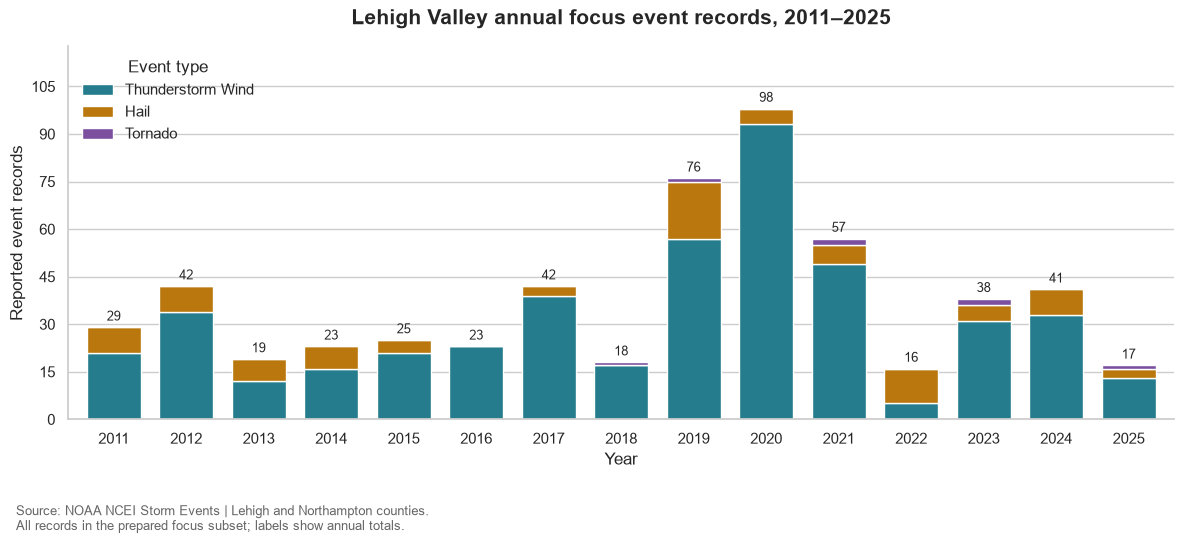

Saved chart: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\reports\figures\lehigh_valley_annual_focus_events_2011_2025.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 5.5))

lehigh_valley_annual_counts[FOCUS_EVENT_TYPES].plot.bar(
    stacked=True,
    color=[EVENT_COLORS[event] for event in FOCUS_EVENT_TYPES],
    width=0.75,
    rot=0,
    ax=ax,
)

ax.bar_label(
    ax.containers[-1],
    labels=lehigh_valley_annual_counts["total_records"],
    padding=3,
    fontsize=9,
)

ax.set_title(
    "Lehigh Valley annual focus event records, 2011–2025",
    fontsize=15,
    fontweight="bold",
    pad=16,
)
ax.set_xlabel("Year")
ax.set_ylabel("Reported event records")
ax.set_ylim(
    0,
    lehigh_valley_annual_counts["total_records"].max() * 1.2,
)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis="x", visible=False)
ax.legend(title="Event type", loc="upper left", frameon=False)
sns.despine(ax=ax)

fig.text(
    0.02, 0.02,
    "Source: NOAA NCEI Storm Events | Lehigh and Northampton counties.\n"
    "All records in the prepared focus subset; labels show annual totals.",
    fontsize=9,
    color="0.4",
)
fig.tight_layout(rect=(0, 0.10, 1, 1))

chart_path = (
    PROJECT_PATHS["figures"]
    / "lehigh_valley_annual_focus_events_2011_2025.png"
)
fig.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved chart:", chart_path)

## Interpreting the Lehigh Valley chart

The three highest annual totals occurred in 2019–2021.

Thunderstorm Wind contributed the largest number of records in 14 of the 15 years. The exception was 2022, when Hail records outnumbered Thunderstorm Wind records.

The local subset contains seven tornado event records across the study period. With such a small total, individual records will have a large influence on the tornado percentages in our monthly comparison.

## Monthly patterns in the Lehigh Valley

We will group the local records by calendar month and event type, combining all years from 2011–2025.

We will retain all 12 months, including months with zero records. This table will support our comparison of local and statewide monthly shares.

The Lehigh Valley records are also included in the statewide dataset.

In [10]:
lehigh_valley_monthly_counts = (
    pd.crosstab(
        lehigh_valley_events["event_month"],
        lehigh_valley_events["EVENT_TYPE"],
    )
    .reindex(
        index=range(1, 13),
        columns=FOCUS_EVENT_TYPES,
        fill_value=0,
    )
    .rename_axis(index="month", columns=None)
)

lehigh_valley_monthly_counts["total_records"] = (
    lehigh_valley_monthly_counts.sum(axis=1)
)

local_monthly_total = int(
    lehigh_valley_monthly_counts["total_records"].sum()
)

print(f"Records in local monthly table: {local_monthly_total:,}")
print(
    "Matches Lehigh Valley subset:",
    local_monthly_total == len(lehigh_valley_events),
)

lehigh_valley_monthly_counts.rename(
    index=lambda month: calendar.month_abbr[month]
)

Records in local monthly table: 564
Matches Lehigh Valley subset: True


,Thunderstorm Wind,Hail,Tornado,total_records
month,,,,
Jan,0,0,0,0
Feb,14,1,0,15
Mar,7,0,0,7
Apr,12,13,0,25
May,40,22,2,64
Jun,108,15,1,124
Jul,144,18,3,165
Aug,79,22,1,102
Sep,31,2,0,33


## Interpreting Lehigh Valley monthly counts

The monthly table accounts for all 564 local records.

July has the largest combined count with 165 records, followed by June with 124 and August with 102.

| Event type | Local peak month(s) | Records in each peak month |
| --- | --- | --- |
| Thunderstorm Wind | July | 144 |
| Hail | May and August | 22 |
| Tornado | July | 3 |

The local Hail distribution has two equally high months. Local Tornado records peak in July, while the statewide Tornado total peaks in May.

## Comparing statewide and local monthly patterns

We will plot monthly percentages for Pennsylvania and the Lehigh Valley, using one panel per event type.

Percentages are calculated separately within each region and event type. All panels will use the same percentage scale, and each legend will show the number of records behind its line.

The local Tornado category contains seven records. Each record therefore represents approximately 14.3% of that category's total, making its monthly percentages sensitive to individual records.

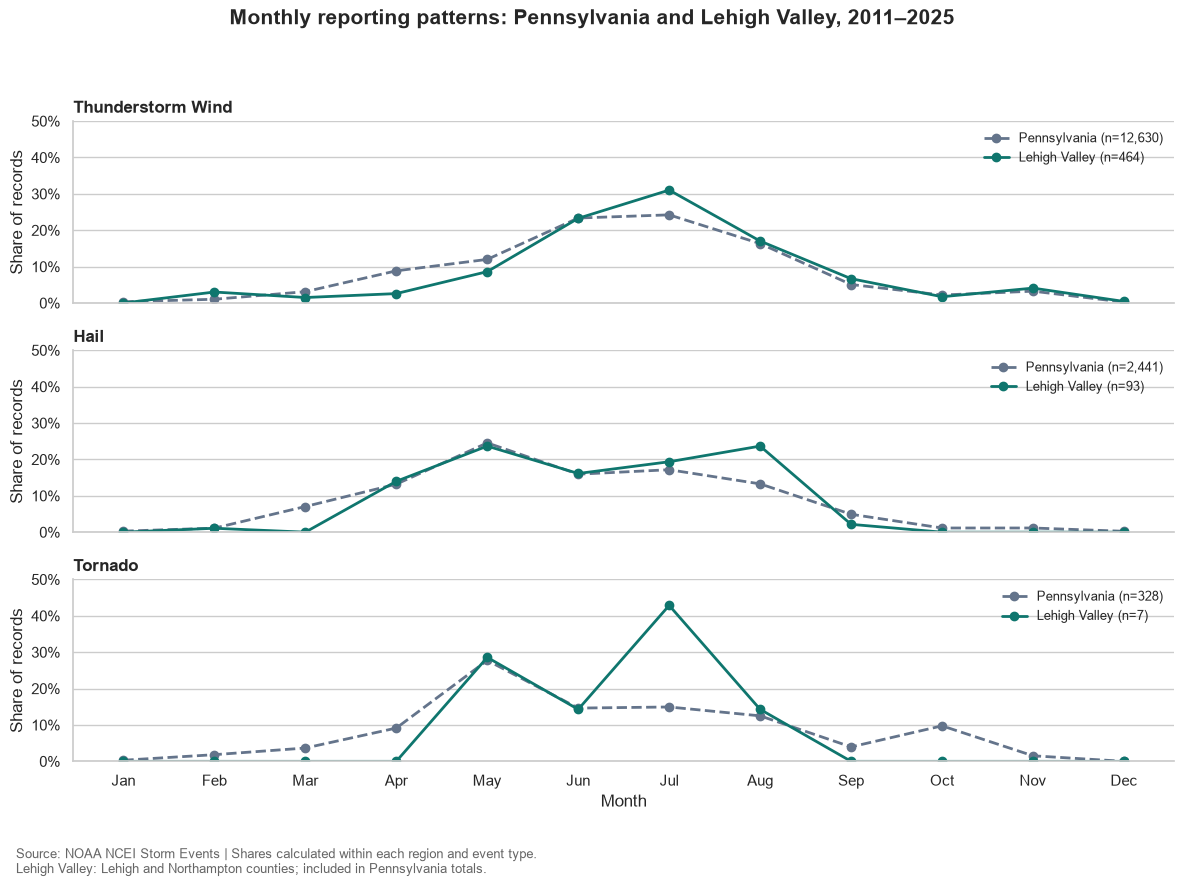

Saved chart: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\reports\figures\pa_lehigh_valley_monthly_comparison_2011_2025.png


In [11]:
statewide_type_totals = monthly_counts[FOCUS_EVENT_TYPES].sum()
local_type_totals = lehigh_valley_monthly_counts[FOCUS_EVENT_TYPES].sum()

lehigh_valley_monthly_percent = (
    lehigh_valley_monthly_counts[FOCUS_EVENT_TYPES]
    .div(local_type_totals, axis="columns")
    .mul(100)
)

fig, axes = plt.subplots(
    3, 1, figsize=(12, 9), sharex=True, sharey=True
)

for ax, event_type in zip(axes, FOCUS_EVENT_TYPES):
    ax.plot(
        monthly_percent.index,
        monthly_percent[event_type],
        color="#64748B",
        linestyle="--",
        marker="o",
        linewidth=2,
        label=f"Pennsylvania (n={statewide_type_totals[event_type]:,})",
    )
    ax.plot(
        lehigh_valley_monthly_percent.index,
        lehigh_valley_monthly_percent[event_type],
        color="#0F766E",
        marker="o",
        linewidth=2,
        label=f"Lehigh Valley (n={local_type_totals[event_type]:,})",
    )

    ax.set_title(event_type, loc="left", fontweight="bold")
    ax.set_ylabel("Share of records")
    ax.set_ylim(0, 50)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
    ax.grid(axis="x", visible=False)
    ax.legend(loc="upper right", frameon=False, fontsize=9)

axes[-1].set_xticks(
    range(1, 13),
    [calendar.month_abbr[month] for month in range(1, 13)],
)
axes[-1].set_xlabel("Month")
sns.despine(fig=fig)

fig.suptitle(
    "Monthly reporting patterns: Pennsylvania and Lehigh Valley, 2011–2025",
    fontsize=15,
    fontweight="bold",
)
fig.text(
    0.02, 0.02,
    "Source: NOAA NCEI Storm Events | Shares calculated within each region and event type.\n"
    "Lehigh Valley: Lehigh and Northampton counties; included in Pennsylvania totals.",
    fontsize=9,
    color="0.4",
)
fig.tight_layout(rect=(0, 0.07, 1, 0.94))

chart_path = (
    PROJECT_PATHS["figures"]
    / "pa_lehigh_valley_monthly_comparison_2011_2025.png"
)
fig.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved chart:", chart_path)

## Interpreting the regional comparison

These monthly shares highlight differences between the local and statewide distributions:

| Event type and month | Pennsylvania | Lehigh Valley |
| --- | --- | --- |
| Thunderstorm Wind — July | 24.2% | 31.0% |
| Hail — August | 13.3% | 23.7% |
| Tornado — July | 14.9% | 42.9% |

Local Hail records are equally concentrated in May and August.

The local July Tornado peak represents three of seven records. That small count limits how broadly we can generalize from the local tornado curve.

## Comparing seasonal totals by region

We will apply the same seasonal groupings to the Lehigh Valley records, then combine the statewide and local summaries into one table.

The percentage column will show each season's share of all three focus event types combined within its region. Each region's percentages will total 100% before rounding.

In [12]:
lehigh_valley_seasonal_counts = pd.DataFrame({
    season: lehigh_valley_monthly_counts.loc[
        months, FOCUS_EVENT_TYPES
    ].sum()
    for season, months in SEASON_MONTHS.items()
}).T.rename_axis("season")

lehigh_valley_seasonal_counts["total_records"] = (
    lehigh_valley_seasonal_counts.sum(axis=1)
)

lehigh_valley_seasonal_counts["percent_of_all_records"] = (
    lehigh_valley_seasonal_counts["total_records"]
    .div(len(lehigh_valley_events))
    .mul(100)
)

seasonal_comparison = pd.concat(
    {
        "Pennsylvania": seasonal_counts,
        "Lehigh Valley": lehigh_valley_seasonal_counts,
    },
    names=["region", "season"],
).rename(
    columns={"percent_of_all_records": "percent_of_region_records"}
)

local_seasonal_total = int(
    lehigh_valley_seasonal_counts["total_records"].sum()
)

print(f"Records in local seasonal table: {local_seasonal_total:,}")
print(
    "Matches Lehigh Valley subset:",
    local_seasonal_total == len(lehigh_valley_events),
)

seasonal_comparison.round(2)

Records in local seasonal table: 564
Matches Lehigh Valley subset: True


Thunderstorm Wind  Hail  Tornado  total_records  \
region        season                                                    
Pennsylvania  Winter                204    40        7            251   
              Spring               3024  1093      133           4250   
              Summer               8072  1132      138           9342   
              Autumn               1330   176       50           1556   
Lehigh Valley Winter                 16     1        0             17   
              Spring                 59    35        2             96   
              Summer                331    55        5            391   
              Autumn                 58     2        0             60   

                      percent_of_region_records  
region        season                             
Pennsylvania  Winter                       1.63  
              Spring                      27.60  
              Summer                      60.67  
              Autumn                      10.10  
Lehigh Valley Winter                       3.01  
              Spring                      17.02  
              Summer                      69.33  
              Autumn                      10.64

## Interpreting the seasonal comparison

The Lehigh Valley's records are more concentrated in summer: 391 records account for 69.33% of its total, compared with 60.67% statewide.

Spring represents a smaller share locally, while autumn's share is similar in both regions.

The local seasonal table accounts for all 564 records. These comparisons describe the distribution of reported event records across 2011–2025.

## Saving Notebook 3 outputs

We will save our annual, monthly, and seasonal tables, including monthly percentages and the regional seasonal comparison.

Year, month, region, and season labels will become regular CSV columns.

After saving, we will reload each file and compare its contents with the original table. The comparison allows tiny floating point differences in percentage values.

In [13]:
notebook3_tables = {
    "pa_annual_focus_counts_2011_2025.csv": annual_counts,
    "pa_monthly_focus_counts_2011_2025.csv": monthly_counts,
    "pa_monthly_focus_percent_2011_2025.csv": monthly_percent,
    "pa_seasonal_focus_counts_2011_2025.csv": seasonal_counts,
    "lehigh_valley_annual_focus_counts_2011_2025.csv": lehigh_valley_annual_counts,
    "lehigh_valley_monthly_focus_counts_2011_2025.csv": lehigh_valley_monthly_counts,
    "lehigh_valley_monthly_focus_percent_2011_2025.csv": lehigh_valley_monthly_percent,
    "lehigh_valley_seasonal_focus_counts_2011_2025.csv": lehigh_valley_seasonal_counts,
    "pa_lehigh_valley_seasonal_comparison_2011_2025.csv": seasonal_comparison,
}

export_checks = []

for filename, table in notebook3_tables.items():
    output_path = PROJECT_PATHS["tables"] / filename
    output_table = table.reset_index()
    output_table.to_csv(output_path, index=False)

    reloaded_table = pd.read_csv(output_path)

    pd.testing.assert_frame_equal(
        reloaded_table,
        output_table,
        check_dtype=False,
        check_exact=False,
        rtol=1e-12,
        atol=1e-12,
    )

    export_checks.append({
        "file": filename,
        "saved_rows": len(reloaded_table),
        "saved_columns": len(reloaded_table.columns),
        "values_match": True,
    })

print("Saved tables to:", PROJECT_PATHS["tables"])

pd.DataFrame(export_checks)

Saved tables to: c:\Users\rcolo\OneDrive\Desktop\Pennsylvania-Severe-Weather-Atlas\reports\tables


,file,saved_rows,saved_columns,values_match
0,pa_annual_focus_counts_2011_2025.csv,15,5,True
1,pa_monthly_focus_counts_2011_2025.csv,12,5,True
2,pa_monthly_focus_percent_2011_2025.csv,12,4,True
3,pa_seasonal_focus_counts_2011_2025.csv,4,6,True
4,lehigh_valley_annual_focus_counts_2011_2025.csv,15,5,True
5,lehigh_valley_monthly_focus_counts_2011_2025.csv,12,5,True
6,lehigh_valley_monthly_focus_percent_2011_2025.csv,12,4,True
7,lehigh_valley_seasonal_focus_counts_2011_2025.csv,4,6,True
8,pa_lehigh_valley_seasonal_comparison_2011_2025...,8,7,True


## Notebook 03 — Conclusions

We examined 15,399 Pennsylvania focus event records from 2011–2025, including 564 records from Lehigh and Northampton counties.

| Measure | Pennsylvania | Lehigh Valley |
| --- | --- | --- |
| Highest annual total | 2019: 1,571 records | 2020: 98 records |
| Highest monthly total, pooled across all years | July: 3,528 records | July: 165 records |
| Summer share of records | 60.67% | 69.33% |

The local distribution was more concentrated in summer. Examining event types separately also revealed differences that combined totals can hide, including different monthly peaks for wind, hail, and tornado records.

Local tornado comparisons require particular care because they involve only seven records.

### Saved outputs

- Nine CSV tables containing annual, monthly, and seasonal summaries were saved to `reports/tables`.
- All nine tables passed checks comparing their reloaded contents with the original tables.
- Four figures were saved to `reports/figures`.

This analysis describes patterns in reported event records. It does not establish the causes of those patterns or demonstrate a climate trend.

**Next:** Examine county-level geographic patterns across Pennsylvania.